In [2]:
!pip install torch torchvision torchaudio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

# Create directories
Path('models').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

print(" All libraries imported successfully!")



 Using device: cpu
 All libraries imported successfully!


In [3]:
# Define SVDRecommender class (from Day 4)
class SVDRecommender:
    """Singular Value Decomposition Recommender"""
    
    def __init__(self, n_factors=50):
        self.n_factors = n_factors
        self.svd_model = None
        self.user_factors = None
        self.product_factors = None
        self.mean_rating = None
        
    def fit(self, R):
        from sklearn.decomposition import TruncatedSVD
        self.mean_rating = np.nanmean(R[R > 0])
        R_centered = R.copy()
        R_centered[R_centered > 0] = R_centered[R_centered > 0] - self.mean_rating
        self.svd_model = TruncatedSVD(n_components=self.n_factors, random_state=42)
        U = self.svd_model.fit_transform(R_centered)
        V = self.svd_model.components_.T
        self.user_factors = U
        self.product_factors = V
        
    def predict(self, user_idx, product_idx=None):
        if product_idx is None:
            predictions = self.user_factors[user_idx] @ self.product_factors.T
        else:
            predictions = self.user_factors[user_idx] @ self.product_factors[product_idx]
        predictions = predictions + self.mean_rating
        predictions = np.clip(predictions, 0, 5)
        return predictions
    
    def recommend(self, user_idx, n_recommendations=10, exclude_seen=True, seen_items=None):
        predictions = self.predict(user_idx)
        if exclude_seen and seen_items is not None:
            predictions[seen_items] = -np.inf
        top_indices = np.argsort(predictions)[::-1][:n_recommendations]
        return top_indices


# Define MatrixFactorization class (from Day 4)
class MatrixFactorization:
    """Non-negative Matrix Factorization Recommender"""
    
    def __init__(self, n_factors=50, learning_rate=0.01, n_epochs=50, lambda_reg=0.01):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.lambda_reg = lambda_reg
        self.user_factors = None
        self.product_factors = None
        self.bias_user = None
        self.bias_product = None
        self.global_bias = None
        self.loss_history = []
        
    def fit(self, R):
        n_users, n_products = R.shape
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.product_factors = np.random.normal(0, 0.1, (self.n_factors, n_products))
        self.bias_user = np.zeros(n_users)
        self.bias_product = np.zeros(n_products)
        self.global_bias = np.mean(R[R > 0]) if np.any(R > 0) else 3.0
        
        for epoch in range(self.n_epochs):
            total_loss = 0
            n_updates = 0
            users, products = np.where(R > 0)
            indices = np.random.permutation(len(users))
            
            for idx in indices:
                u = users[idx]
                p = products[idx]
                rating = R[u, p]
                pred = (self.global_bias + self.bias_user[u] + self.bias_product[p] +
                       self.user_factors[u] @ self.product_factors[:, p])
                error = rating - pred
                self.bias_user[u] += self.learning_rate * (error - self.lambda_reg * self.bias_user[u])
                self.bias_product[p] += self.learning_rate * (error - self.lambda_reg * self.bias_product[p])
                self.user_factors[u] += self.learning_rate * (error * self.product_factors[:, p] - 
                                                             self.lambda_reg * self.user_factors[u])
                self.product_factors[:, p] += self.learning_rate * (error * self.user_factors[u] - 
                                                                   self.lambda_reg * self.product_factors[:, p])
                total_loss += error ** 2
                n_updates += 1
            
            rmse = np.sqrt(total_loss / n_updates) if n_updates > 0 else 0
            self.loss_history.append(rmse)
        
    def predict(self, user_idx, product_idx=None):
        if product_idx is None:
            predictions = (self.global_bias + self.bias_user[user_idx] + self.bias_product +
                          self.user_factors[user_idx] @ self.product_factors)
        else:
            predictions = (self.global_bias + self.bias_user[user_idx] + 
                          self.bias_product[product_idx] +
                          self.user_factors[user_idx] @ self.product_factors[:, product_idx])
        predictions = np.clip(predictions, 0, 5)
        return predictions
    
    def recommend(self, user_idx, n_recommendations=10, exclude_seen=True, seen_items=None):
        predictions = self.predict(user_idx)
        if exclude_seen and seen_items is not None:
            predictions[seen_items] = -np.inf
        top_indices = np.argsort(predictions)[::-1][:n_recommendations]
        return top_indices

print(" Class definitions loaded")
# Load data
train_matrix = np.load('data/processed/train_interaction_matrix.npy')
test_matrix = np.load('data/processed/test_interaction_matrix.npy')

# Load previous models and metrics
with open('models/svd_model.pkl', 'rb') as f:
    svd_model = pickle.load(f)

with open('models/mf_model.pkl', 'rb') as f:
    mf_model = pickle.load(f)

svd_predictions = np.load('models/svd_predictions.npy', allow_pickle=True)
mf_predictions = np.load('models/mf_predictions.npy', allow_pickle=True)

# Load baseline results
baseline_results = pd.read_csv('results/baseline_models_results.csv')

print("=" * 70)
print(" PREVIOUS MODELS LOADED")
print("=" * 70)
print(f"\n SVD Model loaded")
print(f" Matrix Factorization Model loaded")
print(f" Previous predictions loaded")
print(f" Baseline results loaded\n")
print("Baseline results:")
print(baseline_results.to_string(index=False))


 Class definitions loaded
 PREVIOUS MODELS LOADED

 SVD Model loaded
 Matrix Factorization Model loaded
 Previous predictions loaded
 Baseline results loaded

Baseline results:
               Model  Precision@10  Recall@10  NDCG@10  Hit Rate@10   MAP@10     RMSE      MAE
                 SVD      0.003611   0.020984 0.011957     0.034537 0.007475 1.185375 0.968459
Matrix Factorization      0.002983   0.018629 0.009630     0.029827 0.005467 1.280261 1.041480


In [4]:
class NeuralCollaborativeFiltering(nn.Module):
    """
    Neural Collaborative Filtering (NCF) Model
    
    Uses neural networks to learn user-product interactions
    Architecture:
    - Embedding layers for users and products
    - Concatenate embeddings
    - Dense layers with activation
    - Output: predicted rating
    """
    
    def __init__(self, n_users, n_products, n_factors=32, hidden_dims=[64, 32, 16]):
        """
        Initialize NCF model
        
        Args:
            n_users: Number of users
            n_products: Number of products
            n_factors: Embedding dimension
            hidden_dims: Hidden layer dimensions
        """
        super(NeuralCollaborativeFiltering, self).__init__()
        
        self.n_users = n_users
        self.n_products = n_products
        self.n_factors = n_factors
        
        # Embedding layers
        self.user_embedding = nn.Embedding(n_users, n_factors)
        self.product_embedding = nn.Embedding(n_products, n_factors)
        
        # Initialize embeddings
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.product_embedding.weight, std=0.01)
        
        # Dense layers
        layers = []
        input_size = n_factors * 2  # User + product embedding concatenated
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_size, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            input_size = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(input_size, 1))
        
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, user_ids, product_ids):
        """
        Forward pass
        
        Args:
            user_ids: User indices (batch_size,)
            product_ids: Product indices (batch_size,)
            
        Returns:
            Predicted ratings (batch_size, 1)
        """
        # Get embeddings
        user_emb = self.user_embedding(user_ids)  # (batch_size, n_factors)
        product_emb = self.product_embedding(product_ids)  # (batch_size, n_factors)
        
        # Concatenate embeddings
        x = torch.cat([user_emb, product_emb], dim=1)  # (batch_size, 2*n_factors)
        
        # Pass through MLP
        output = self.mlp(x)  # (batch_size, 1)
        
        # Clip to valid rating range [0, 5]
        output = torch.clamp(output, 0, 5)
        
        return output

print(" Neural Collaborative Filtering class created")


 Neural Collaborative Filtering class created


In [5]:
print("=" * 70)
print(" PREPARING DATA FOR NEURAL TRAINING")
print("=" * 70)

# Get non-zero indices from training matrix
train_users, train_products = np.where(train_matrix > 0)
train_ratings = train_matrix[train_users, train_products]

# Convert to tensors
train_users_tensor = torch.tensor(train_users, dtype=torch.long)
train_products_tensor = torch.tensor(train_products, dtype=torch.long)
train_ratings_tensor = torch.tensor(train_ratings, dtype=torch.float32).unsqueeze(1)

# Create dataset
train_dataset = TensorDataset(train_users_tensor, train_products_tensor, train_ratings_tensor)

# Create dataloader
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"\n Training data prepared")
print(f"  Total interactions: {len(train_dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Total batches: {len(train_dataloader)}")
print(f"  User range: 0 - {train_matrix.shape[0]-1}")
print(f"  Product range: 0 - {train_matrix.shape[1]-1}")


 PREPARING DATA FOR NEURAL TRAINING

 Training data prepared
  Total interactions: 3978
  Batch size: 32
  Total batches: 125
  User range: 0 - 993
  Product range: 0 - 499


In [20]:
def train_ncf(model, dataloader, n_epochs=50, learning_rate=0.001, device='cpu', verbose=True):
    """
    Train NCF model
    
    Args:
        model: NCF model instance
        dataloader: Training dataloader
        n\_epochs: Number of epochs
        learning\_rate: Learning rate
        device: 'cpu' or 'cuda'
        verbose: Print progress
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()
    
    loss_history = []
    
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        n_batches = 0
        
        for batch_users, batch_products, batch_ratings in dataloader:
            # Move to device
            batch_users = batch_users.to(device)
            batch_products = batch_products.to(device)
            batch_ratings = batch_ratings.to(device)
            
            # Forward pass
            predictions = model(batch_users, batch_products)
            
            # Compute loss
            loss = loss_fn(predictions, batch_ratings)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs} - Loss: {avg_loss:.4f}")
    
    if verbose:
        print(f" Training complete! Final loss: {loss_history[-1]:.4f}")
    
    return loss_history

print(" Training function defined")

# Initialize NCF model
ncf_model = NeuralCollaborativeFiltering(
    n_users=train_matrix.shape[0],
    n_products=train_matrix.shape[1],
    n_factors=32,
    hidden_dims=[64, 32, 16]
)

print(f"\n NCF model initialized")
print(f"  Architecture:")
print(f"  - User embedding: {train_matrix.shape[0]} users → 32 factors")
print(f"  - Product embedding: {train_matrix.shape[1]} products → 32 factors")
print(f"  - Hidden layers: \[64, 32, 16]")

# Train model
print(f"\n Starting training...")
ncf_loss_history = train_ncf(
    ncf_model,
    train_dataloader,
    n_epochs=50,
    learning_rate=0.001,
    device=device,
    verbose=True
)

# Save model
torch.save(ncf_model.state_dict(), 'models/ncf_model.pt')
print(f"\n NCF model saved: models/ncf_model.pt")


 Training function defined

 NCF model initialized
  Architecture:
  - User embedding: 994 users → 32 factors
  - Product embedding: 500 products → 32 factors
  - Hidden layers: \[64, 32, 16]

 Starting training...
Epoch 10/50 - Loss: 16.0028
Epoch 20/50 - Loss: 16.0034
Epoch 30/50 - Loss: 16.0044
Epoch 40/50 - Loss: 16.0193
Epoch 50/50 - Loss: 16.0072
 Training complete! Final loss: 16.0072

 NCF model saved: models/ncf_model.pt


In [26]:
print("=" * 70)
print(" GENERATING NCF PREDICTIONS")
print("=" * 70)

ncf_model.eval()
ncf_predictions = []

with torch.no_grad():
    for user_idx in range(train_matrix.shape[0]):
        # Get items user has seen
        seen_items = np.where(train_matrix[user_idx] > 0)[0]
        
        # Get predictions for all products
        all_user_ids = torch.full((train_matrix.shape[1],), user_idx, dtype=torch.long).to(device)
        all_product_ids = torch.arange(train_matrix.shape[1], dtype=torch.long).to(device)
        
        with torch.no_grad():
            all_predictions = ncf_model(all_user_ids, all_product_ids)
        
        predictions = all_predictions.cpu().numpy().flatten()
        
        # Exclude seen items
        predictions[seen_items] = -np.inf
        
        # Get top-10 recommendations
        top_indices = np.argsort(predictions)[::-1][:10]
        
        ncf_predictions.append(top_indices)

print(f" Predictions generated for {len(ncf_predictions)} users")
print(f"\nExample recommendation for user 0:")
print(f"  Top-10 products: {ncf_predictions[0]}")

# Save predictions
np.save('models/ncf_predictions.npy', ncf_predictions)
print(f"\n NCF predictions saved")

 GENERATING NCF PREDICTIONS
 Predictions generated for 994 users

Example recommendation for user 0:
  Top-10 products: [  0 499 498 497  16  17  18  19  20  21]

 NCF predictions saved


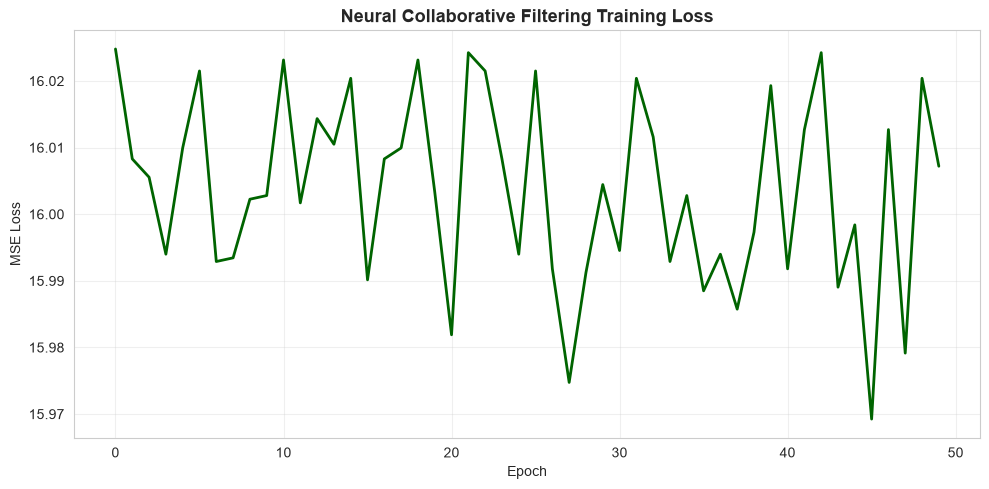

 Training loss visualized

Loss Summary:
  Initial loss: 16.0248
  Final loss: 16.0072
  Improvement: 0.1%


In [28]:
plt.figure(figsize=(10, 5))
plt.plot(ncf_loss_history, linewidth=2, color='darkgreen')
plt.title('Neural Collaborative Filtering Training Loss', fontweight='bold', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f" Training loss visualized")
print(f"\nLoss Summary:")
print(f"  Initial loss: {ncf_loss_history[0]:.4f}")
print(f"  Final loss: {ncf_loss_history[-1]:.4f}")
print(f"  Improvement: {(ncf_loss_history[0] - ncf_loss_history[-1]) / ncf_loss_history[0] * 100:.1f}%")


In [32]:
# Import the metrics class from previous notebook
from pathlib import Path
import sys

# Copy the metrics class (from Day 4)
class RecommendationMetrics:
    """Metrics for evaluating recommendations"""
    
    @staticmethod
    def precision_at_k(actual, predicted, k=10):
        if len(predicted) == 0:
            return 0.0
        predicted_k = predicted[:k]
        relevant = len(set(actual) & set(predicted_k))
        return relevant / k
    
    @staticmethod
    def recall_at_k(actual, predicted, k=10):
        if len(actual) == 0:
            return 0.0
        predicted_k = predicted[:k]
        relevant = len(set(actual) & set(predicted_k))
        return relevant / len(actual)
    
    @staticmethod
    def ndcg_at_k(actual, predicted, k=10):
        if len(actual) == 0:
            return 0.0
        predicted_k = predicted[:k]
        dcg = sum(1.0 / np.log2(i + 1) for i, item in enumerate(predicted_k, 1) if item in actual)
        ideal_k = min(len(actual), k)
        idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_k + 1))
        return dcg / idcg if idcg > 0 else 0.0
    
    @staticmethod
    def hit_rate(actual, predicted, k=10):
        predicted_k = predicted[:k]
        return 1.0 if len(set(actual) & set(predicted_k)) > 0 else 0.0
    
    @staticmethod
    def mean_average_precision(actual, predicted, k=10):
        if len(actual) == 0:
            return 0.0
        predicted_k = predicted[:k]
        score = 0.0
        hits = 0.0
        for i, item in enumerate(predicted_k, 1):
            if item in actual:
                hits += 1.0
                score += hits / i
        return score / min(len(actual), k)

print(" Metrics class loaded")

 Metrics class loaded


In [34]:
print("=" * 70)
print(" EVALUATING NCF MODEL")
print("=" * 70)

def evaluate_model(predictions, test_matrix, k_values=[5, 10]):
    """Evaluate ranking metrics"""
    metrics = {}
    
    for k in k_values:
        precision_scores = []
        recall_scores = []
        ndcg_scores = []
        hit_rate_scores = []
        map_scores = []
        
        for user_idx, pred_items in enumerate(predictions):
            actual_items = np.where(test_matrix[user_idx] > 0)[0]
            
            if len(actual_items) == 0:
                continue
            
            precision = RecommendationMetrics.precision_at_k(actual_items, pred_items, k)
            recall = RecommendationMetrics.recall_at_k(actual_items, pred_items, k)
            ndcg = RecommendationMetrics.ndcg_at_k(actual_items, pred_items, k)
            hit_rate = RecommendationMetrics.hit_rate(actual_items, pred_items, k)
            map_score = RecommendationMetrics.mean_average_precision(actual_items, pred_items, k)
            
            precision_scores.append(precision)
            recall_scores.append(recall)
            ndcg_scores.append(ndcg)
            hit_rate_scores.append(hit_rate)
            map_scores.append(map_score)
        
        metrics[f'Precision@{k}'] = np.mean(precision_scores)
        metrics[f'Recall@{k}'] = np.mean(recall_scores)
        metrics[f'NDCG@{k}'] = np.mean(ndcg_scores)
        metrics[f'Hit Rate@{k}'] = np.mean(hit_rate_scores)
        metrics[f'MAP@{k}'] = np.mean(map_scores)
    
    return metrics

# Evaluate NCF
ncf_metrics = evaluate_model(ncf_predictions, test_matrix)

print("\n Neural Collaborative Filtering Results:")
for metric, value in ncf_metrics.items():
    print(f"  {metric}: {value:.4f}")


 EVALUATING NCF MODEL

 Neural Collaborative Filtering Results:
  Precision@5: 0.0019
  Recall@5: 0.0053
  NDCG@5: 0.0040
  Hit Rate@5: 0.0094
  MAP@5: 0.0029
  Precision@10: 0.0031
  Recall@10: 0.0130
  NDCG@10: 0.0074
  Hit Rate@10: 0.0314
  MAP@10: 0.0039


In [36]:
print("=" * 70)
print("🔗 BUILDING ENSEMBLE MODEL")
print("=" * 70)

class EnsembleRecommender:
    """
    Ensemble model combining SVD, Matrix Factorization, and NCF
    Uses weighted average of predictions
    """
    
    def __init__(self, svd_model, mf_model, ncf_model, weights=None):
        """
        Initialize ensemble
        
        Args:
            svd_model: Trained SVD model
            mf_model: Trained Matrix Factorization model
            ncf_model: Trained NCF model
            weights: [w_svd, w_mf, w_ncf] - should sum to 1.0
        """
        self.svd_model = svd_model
        self.mf_model = mf_model
        self.ncf_model = ncf_model
        
        if weights is None:
            # Equal weights
            self.weights = [1/3, 1/3, 1/3]
        else:
            # Normalize weights
            total = sum(weights)
            self.weights = [w / total for w in weights]
        
        print(f"✓ Ensemble initialized with weights:")
        print(f"  SVD: {self.weights[0]:.3f}")
        print(f"  MF:  {self.weights[1]:.3f}")
        print(f"  NCF: {self.weights[2]:.3f}")
    
    def predict(self, user_idx, product_idx=None):
        """
        Get ensemble prediction
        
        Args:
            user_idx: User index
            product_idx: Product index (or None for all)
            
        Returns:
            Weighted ensemble prediction
        """
        # Get predictions from each model
        svd_pred = self.svd_model.predict(user_idx, product_idx)
        mf_pred = self.mf_model.predict(user_idx, product_idx)
        
        # NCF prediction
        if product_idx is None:
            # All products
            all_product_ids = torch.arange(mf_pred.shape[0], dtype=torch.long).to(device)
            all_user_ids = torch.full_like(all_product_ids, user_idx)
            
            with torch.no_grad():
                ncf_out = self.ncf_model(all_user_ids, all_product_ids)
            ncf_pred = ncf_out.cpu().numpy().flatten()
        else:
            # Single product
            user_tensor = torch.tensor([user_idx], dtype=torch.long).to(device)
            product_tensor = torch.tensor([product_idx], dtype=torch.long).to(device)
            
            with torch.no_grad():
                ncf_out = self.ncf_model(user_tensor, product_tensor)
            ncf_pred = ncf_out.cpu().item()
        
        # Weighted ensemble
        ensemble_pred = (self.weights[0] * svd_pred + 
                        self.weights[1] * mf_pred + 
                        self.weights[2] * ncf_pred)
        
        # Clip to valid range
        ensemble_pred = np.clip(ensemble_pred, 0, 5)
        
        return ensemble_pred
    
    def recommend(self, user_idx, n_recommendations=10, exclude_seen=True, seen_items=None):
        """Get top-N recommendations"""
        predictions = self.predict(user_idx)
        
        if exclude_seen and seen_items is not None:
            predictions[seen_items] = -np.inf
        
        top_indices = np.argsort(predictions)[::-1][:n_recommendations]
        
        return top_indices


# Create ensemble with equal weights
ensemble = EnsembleRecommender(
    svd_model=svd_model,
    mf_model=mf_model,
    ncf_model=ncf_model,
    weights=[1, 1, 1]  # Equal weights (will be normalized)
)

# Generate ensemble predictions
print("\n Generating ensemble predictions...")
ensemble_predictions = []

for user_idx in range(train_matrix.shape[0]):
    seen_items = np.where(train_matrix[user_idx] > 0)[0]
    
    recommendations = ensemble.recommend(
        user_idx,
        n_recommendations=10,
        exclude_seen=True,
        seen_items=seen_items
    )
    
    ensemble_predictions.append(recommendations)

np.save('models/ensemble_predictions.npy', ensemble_predictions)
print(f"✓ Ensemble predictions saved")
print(f"\nExample recommendation for user 0:")
print(f"  Top-10 products: {ensemble_predictions[0]}")

🔗 BUILDING ENSEMBLE MODEL
✓ Ensemble initialized with weights:
  SVD: 0.333
  MF:  0.333
  NCF: 0.333

 Generating ensemble predictions...
✓ Ensemble predictions saved

Example recommendation for user 0:
  Top-10 products: [402 490 273 187 443  36 406 195 397  66]


In [38]:
print("=" * 70)
print(" COMPREHENSIVE MODEL COMPARISON")
print("=" * 70)

# Evaluate ensemble
ensemble_metrics = evaluate_model(ensemble_predictions, test_matrix)

print("\n🔗 Ensemble Model Results:")
for metric, value in ensemble_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Create comparison dataframe
metrics_list = []

# SVD metrics
for metric_name, metric_value in baseline_results[baseline_results['Model'] == 'SVD'].iloc[0].items():
    if metric_name != 'Model':
        metrics_list.append({'Model': 'SVD', 'Metric': metric_name, 'Value': metric_value})

# MF metrics
for metric_name, metric_value in baseline_results[baseline_results['Model'] == 'Matrix Factorization'].iloc[0].items():
    if metric_name != 'Model':
        metrics_list.append({'Model': 'Matrix Factorization', 'Metric': metric_name, 'Value': metric_value})

# NCF metrics
for metric_name, metric_value in ncf_metrics.items():
    metrics_list.append({'Model': 'Neural CF', 'Metric': metric_name, 'Value': metric_value})

# Ensemble metrics
for metric_name, metric_value in ensemble_metrics.items():
    metrics_list.append({'Model': 'Ensemble', 'Metric': metric_name, 'Value': metric_value})

df_all_metrics = pd.DataFrame(metrics_list)

# Pivot for better visualization
comparison_table = df_all_metrics.pivot(index='Metric', columns='Model', values='Value')

print("\n" + "=" * 70)
print(" ALL MODELS COMPARISON")
print("=" * 70)
print(comparison_table.round(4).to_string())

# Find best model for each metric
print("\n\n BEST MODEL PER METRIC:")
for metric in comparison_table.index:
    if 'RMSE' in metric or 'MAE' in metric:
        best = comparison_table.loc[metric].idxmin()
    else:
        best = comparison_table.loc[metric].idxmax()
    
    best_value = comparison_table.loc[metric, best]
    print(f"  {metric:15s}: {best:25s} ({best_value:.4f})")


 COMPREHENSIVE MODEL COMPARISON

🔗 Ensemble Model Results:
  Precision@5: 0.0038
  Recall@5: 0.0119
  NDCG@5: 0.0094
  Hit Rate@5: 0.0188
  MAP@5: 0.0073
  Precision@10: 0.0033
  Recall@10: 0.0190
  NDCG@10: 0.0121
  Hit Rate@10: 0.0330
  MAP@10: 0.0082

 ALL MODELS COMPARISON
Model         Ensemble  Matrix Factorization  Neural CF     SVD
Metric                                                         
Hit Rate@10     0.0330                0.0298     0.0314  0.0345
Hit Rate@5      0.0188                   NaN     0.0094     NaN
MAE                NaN                1.0415        NaN  0.9685
MAP@10          0.0082                0.0055     0.0039  0.0075
MAP@5           0.0073                   NaN     0.0029     NaN
NDCG@10         0.0121                0.0096     0.0074  0.0120
NDCG@5          0.0094                   NaN     0.0040     NaN
Precision@10    0.0033                0.0030     0.0031  0.0036
Precision@5     0.0038                   NaN     0.0019     NaN
RMSE              

In [40]:
# Create comprehensive results dataframe
complete_results = pd.DataFrame({
    'Model': ['SVD', 'Matrix Factorization', 'Neural CF', 'Ensemble'],
    'Precision@10': [
        baseline_results[baseline_results['Model'] == 'SVD']['Precision@10'].values[0],
        baseline_results[baseline_results['Model'] == 'Matrix Factorization']['Precision@10'].values[0],
        ncf_metrics['Precision@10'],
        ensemble_metrics['Precision@10']
    ],
    'Recall@10': [
        baseline_results[baseline_results['Model'] == 'SVD']['Recall@10'].values[0],
        baseline_results[baseline_results['Model'] == 'Matrix Factorization']['Recall@10'].values[0],
        ncf_metrics['Recall@10'],
        ensemble_metrics['Recall@10']
    ],
    'NDCG@10': [
        baseline_results[baseline_results['Model'] == 'SVD']['NDCG@10'].values[0],
        baseline_results[baseline_results['Model'] == 'Matrix Factorization']['NDCG@10'].values[0],
        ncf_metrics['NDCG@10'],
        ensemble_metrics['NDCG@10']
    ],
    'Hit Rate@10': [
        baseline_results[baseline_results['Model'] == 'SVD']['Hit Rate@10'].values[0],
        baseline_results[baseline_results['Model'] == 'Matrix Factorization']['Hit Rate@10'].values[0],
        ncf_metrics['Hit Rate@10'],
        ensemble_metrics['Hit Rate@10']
    ],
    'MAP@10': [
        baseline_results[baseline_results['Model'] == 'SVD']['MAP@10'].values[0],
        baseline_results[baseline_results['Model'] == 'Matrix Factorization']['MAP@10'].values[0],
        ncf_metrics['MAP@10'],
        ensemble_metrics['MAP@10']
    ],
})

complete_results.to_csv('results/all_models_comparison.csv', index=False)
print(" Complete results saved: results/all_models_comparison.csv")

print("\n" + "=" * 70)
print(" FINAL RESULTS SUMMARY")
print("=" * 70)
print(complete_results.to_string(index=False))

 Complete results saved: results/all_models_comparison.csv

 FINAL RESULTS SUMMARY
               Model  Precision@10  Recall@10  NDCG@10  Hit Rate@10   MAP@10
                 SVD      0.003611   0.020984 0.011957     0.034537 0.007475
Matrix Factorization      0.002983   0.018629 0.009630     0.029827 0.005467
           Neural CF      0.003140   0.012977 0.007423     0.031397 0.003908
            Ensemble      0.003297   0.018995 0.012149     0.032967 0.008189


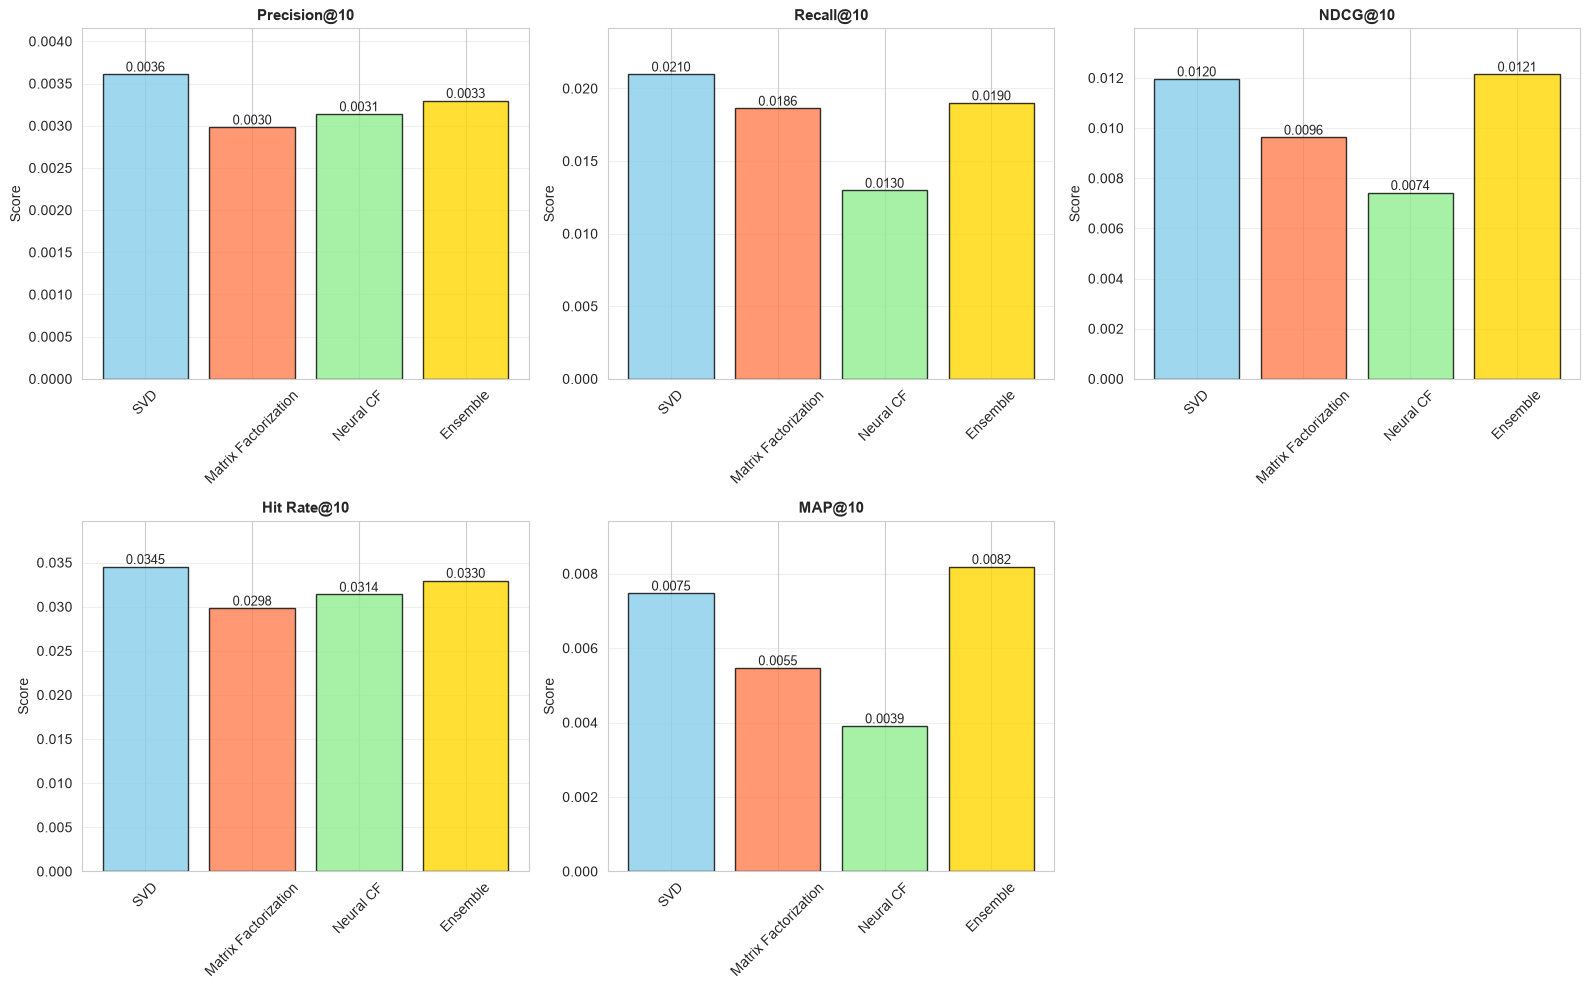

 Model comparison charts created


In [42]:
# Prepare data for visualization
metrics_to_plot = ['Precision@10', 'Recall@10', 'NDCG@10', 'Hit Rate@10', 'MAP@10']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    values = complete_results[metric].values
    models = complete_results['Model'].values
    
    colors = ['skyblue', 'coral', 'lightgreen', 'gold']
    bars = ax.bar(models, values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)
    
    ax.set_title(f'{metric}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim([0, max(values) * 1.15])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

print(" Model comparison charts created")

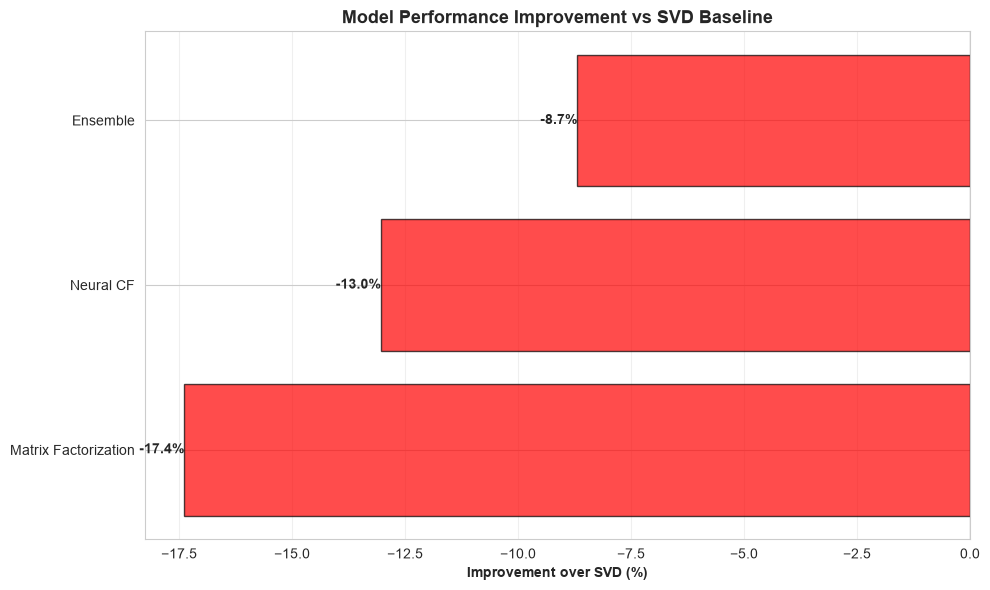

 Improvement chart created


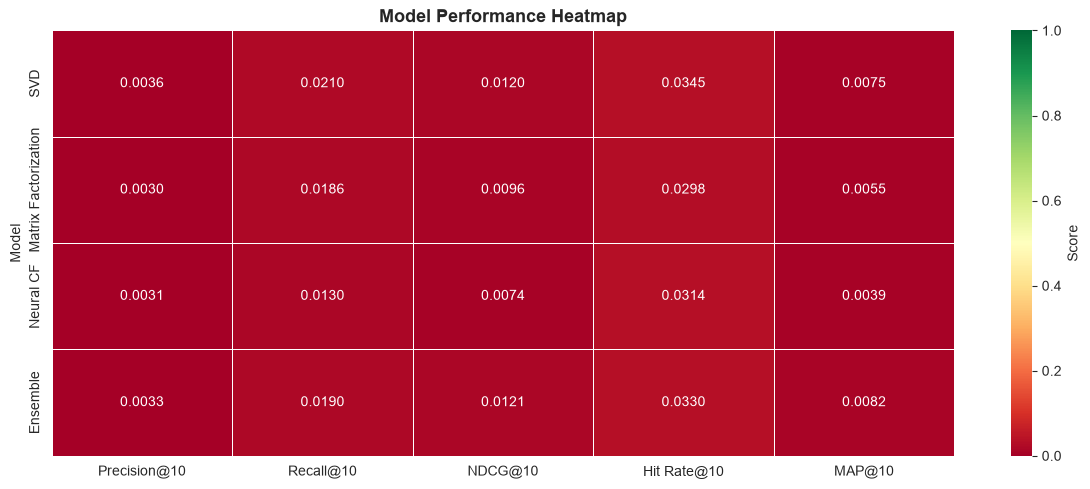

Heatmap created


In [46]:
# Calculate improvements over SVD baseline
svd_precision = complete_results[complete_results['Model'] == 'SVD']['Precision@10'].values[0]
improvements = []

for idx, row in complete_results.iterrows():
    if row['Model'] != 'SVD':
        improvement = ((row['Precision@10'] - svd_precision) / svd_precision * 100)
        improvements.append({
            'Model': row['Model'],
            'Improvement': improvement,
            'Precision@10': row['Precision@10']
        })

df_improvements = pd.DataFrame(improvements)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['red' if x < 0 else 'green' for x in df_improvements['Improvement']]
bars = ax.barh(df_improvements['Model'], df_improvements['Improvement'], color=colors, alpha=0.7, edgecolor='black')

# Add value labels
for idx, (bar, val) in enumerate(zip(bars, df_improvements['Improvement'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:+.1f}%', 
            ha='left' if val > 0 else 'right', va='center', fontweight='bold')

ax.set_xlabel('Improvement over SVD (%)', fontweight='bold')
ax.set_title('Model Performance Improvement vs SVD Baseline', fontweight='bold', fontsize=13)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(" Improvement chart created")

# Create heatmap of all metrics
metrics_heatmap = complete_results.set_index('Model')[metrics_to_plot]

plt.figure(figsize=(12, 5))
sns.heatmap(metrics_heatmap, annot=True, fmt='.4f', cmap='RdYlGn', 
            cbar_kws={'label': 'Score'}, vmin=0, vmax=1, linewidths=0.5)
plt.title('Model Performance Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Heatmap created")


In [ ]:
print("=" * 70)
print(" HYPERPARAMETER OPTIMIZATION FOR NCF")
print("=" * 70)

# Try different configurations
ncf_configs = [
    {'n_factors': 16, 'hidden_dims': [32, 16], 'lr': 0.001, 'epochs': 30},
    {'n_factors': 32, 'hidden_dims': [64, 32, 16], 'lr': 0.001, 'epochs': 50},
    {'n_factors': 64, 'hidden_dims': [128, 64, 32], 'lr': 0.001, 'epochs': 50},
    {'n_factors': 32, 'hidden_dims': [64, 32, 16], 'lr': 0.0005, 'epochs': 50},
    {'n_factors': 32, 'hidden_dims': [64, 32, 16], 'lr': 0.005, 'epochs': 50},
]

optimization_results = []

for config_idx, config in enumerate(ncf_configs, 1):
    print(f"\n\nConfig {config_idx}: {config}")
    
    # Create model
    tuned_model = NeuralCollaborativeFiltering(
        n_users=train_matrix.shape[0],
        n_products=train_matrix.shape[1],
        n_factors=config['n_factors'],
        hidden_dims=config['hidden_dims']
    )
    
    # Train
    loss_history = train_ncf(
        tuned_model,
        train_dataloader,
        n_epochs=config['epochs'],
        learning_rate=config['lr'],
        device=device,
        verbose=False
    )
    
    # Generate predictions
    tuned_model.eval()
    tuned_predictions = []
    
    with torch.no_grad():
        for user_idx in range(train_matrix.shape[0]):
            seen_items = np.where(train_matrix[user_idx] > 0)[0]
            all_user_ids = torch.full((train_matrix.shape[1],), user_idx, dtype=torch.long).to(device)
            all_product_ids = torch.arange(train_matrix.shape[1], dtype=torch.long).to(device)
            all_predictions = tuned_model(all_user_ids, all_product_ids)
            predictions = all_predictions.cpu().numpy().flatten()
            predictions[seen_items] = -np.inf
            top_indices = np.argsort(predictions)[::-1][:10]
            tuned_predictions.append(top_indices)
    
    # Evaluate
    tuned_metrics = evaluate_model(tuned_predictions, test_matrix)
    
    # Store results
    optimization_results.append({
        'Config': config_idx,
        'n_factors': config['n_factors'],
        'hidden_dims': str(config['hidden_dims']),
        'lr': config['lr'],
        'epochs': config['epochs'],
        'Final Loss': loss_history[-1],
        'Precision@10': tuned_metrics['Precision@10'],
        'Recall@10': tuned_metrics['Recall@10'],
        'NDCG@10': tuned_metrics['NDCG@10'],
    })
    
    print(f"✓ Config {config_idx} - Precision@10: {tuned_metrics['Precision@10']:.4f}")

df_optimization = pd.DataFrame(optimization_results)
df_optimization.to_csv('results/hyperparameter_optimization.csv', index=False)

print("\n" + "=" * 70)
print(" HYPERPARAMETER OPTIMIZATION RESULTS")
print("=" * 70)
print(df_optimization.to_string(index=False))

# Find best configuration
best_idx = df_optimization['Precision@10'].idxmax()
best_config = df_optimization.iloc[best_idx]

print(f"\n\n BEST CONFIGURATION:")
print(f"  Config {best_config['Config']}")
print(f"  Precision@10: {best_config['Precision@10']:.4f}")

 HYPERPARAMETER OPTIMIZATION FOR NCF


Config 1: {'n_factors': 16, 'hidden_dims': [32, 16], 'lr': 0.001, 'epochs': 30}
✓ Config 1 - Precision@10: 0.0038


Config 2: {'n_factors': 32, 'hidden_dims': [64, 32, 16], 'lr': 0.001, 'epochs': 50}
